<a href="https://www.kaggle.com/code/lunorabloom/wellness-audit-fitlife360-eda-insights?scriptVersionId=318113527" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Wellness Audit: FitLife360 EDA & Insights

Created by Jennifer Johnson

Certified Nutritionist | Data Analytics Professional

Focused on Healthcare Analytics, Wearable Health Data, and Predictive Wellness Insights

## Project Overview

This healthcare wellness audit analyzes wearable fitness and activity data to identify relationships between calorie expenditure, exercise intensity, BMI, and metabolic health indicators. The project uses exploratory data analysis and predictive modeling techniques to uncover patterns that may support preventative healthcare and wellness optimization.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, f_oneway, kruskal, linregress, spearmanr

# Load the dataset
df = pd.read_csv('/kaggle/input/fitlife-health-and-fitness-tracking-dataset/health_fitness_dataset.csv')

# Calculate BMI
df['bmi'] = df['weight_kg'] / ((df['height_cm'] / 100) ** 2)

# Show first rows
df.head()

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,3,7128,1.5,19.652988,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7,7925,1.8,19.726183,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7,7557,2.7,19.835976,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,8,11120,2.6,19.909172,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,1,5406,1.5,20.018965,69.5,110.7,72.9,NaN,Never,0.33


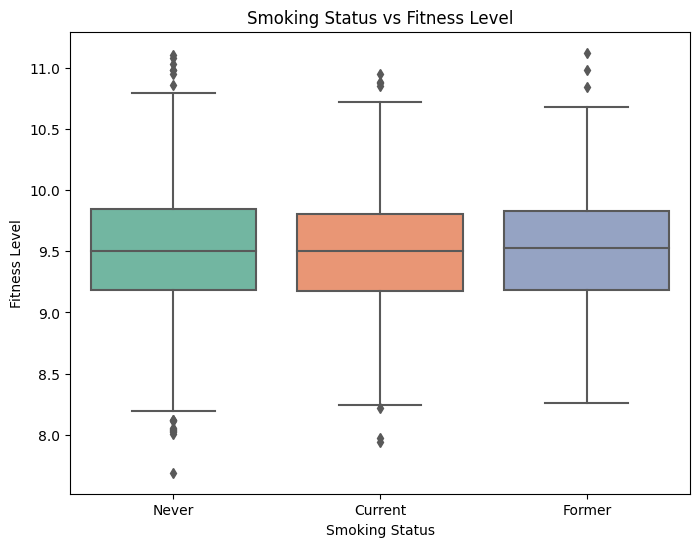

ANOVA Result for Smoking vs Fitness Level: F-statistic = 0.01570659097752356, P-value = 0.9844161952869449


In [2]:
fitness_with_health_df = df.groupby('participant_id').agg({
    'fitness_level': 'mean',
    'smoking_status': 'first',
    'health_condition': 'first'
}).reset_index()

plt.figure(figsize=(8, 6))

sns.boxplot(
    x='smoking_status',
    y='fitness_level',
    data=fitness_with_health_df,
    palette='Set2'
)

plt.title('Smoking Status vs Fitness Level')
plt.xlabel('Smoking Status')
plt.ylabel('Fitness Level')

plt.show()

groups = [
    fitness_with_health_df[
        fitness_with_health_df['smoking_status'] == cat
    ]['fitness_level']
    for cat in fitness_with_health_df['smoking_status'].unique()
]

anova_result = f_oneway(*groups)

print(
    f"ANOVA Result for Smoking vs Fitness Level: "
    f"F-statistic = {anova_result.statistic}, "
    f"P-value = {anova_result.pvalue}"
)

In [3]:
list_of_columns = []

for column in df:
    list_of_columns.append(column)

print(list_of_columns)

['participant_id', 'date', 'age', 'gender', 'height_cm', 'weight_kg', 'activity_type', 'duration_minutes', 'intensity', 'calories_burned', 'avg_heart_rate', 'hours_sleep', 'stress_level', 'daily_steps', 'hydration_level', 'bmi', 'resting_heart_rate', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'health_condition', 'smoking_status', 'fitness_level']


Health condition contains many missing values, so missing entries were reviewed before using this variable in later analysis.

In [4]:
for column in list_of_columns:
    print(f"Column {column} has {df[column].isna().sum()} missing values")

Column participant_id has 0 missing values
Column date has 0 missing values
Column age has 0 missing values
Column gender has 0 missing values
Column height_cm has 0 missing values
Column weight_kg has 0 missing values
Column activity_type has 0 missing values
Column duration_minutes has 0 missing values
Column intensity has 0 missing values
Column calories_burned has 0 missing values
Column avg_heart_rate has 0 missing values
Column hours_sleep has 0 missing values
Column stress_level has 0 missing values
Column daily_steps has 0 missing values
Column hydration_level has 0 missing values
Column bmi has 0 missing values
Column resting_heart_rate has 0 missing values
Column blood_pressure_systolic has 0 missing values
Column blood_pressure_diastolic has 0 missing values
Column health_condition has 490275 missing values
Column smoking_status has 0 missing values
Column fitness_level has 0 missing values


### Healthcare Insight

**Initial analysis suggests that BMI, activity intensity, and caloric expenditure may have measurable relationships relevant to preventative wellness monitoring and metabolic health assessment.**

# Exploratory Data Analysis

**This section reviews the size, structure, and completeness of the FitLife360 dataset before deeper analysis.**

## Data Distribution

**This section explores participant activity patterns, sample sizes, and exercise distribution to better understand the structure of the dataset.**

In [5]:
df.describe()

,participant_id,age,height_cm,weight_kg,duration_minutes,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,fitness_level
count,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000,687701.000000
mean,1499.781828,41.658602,168.587699,94.921981,70.011671,15.381302,131.454165,7.048799,5.252389,8628.370918,2.499427,33.289632,70.010547,120.001260,80.188079,9.524900
std,865.997215,13.581770,9.140811,22.461801,29.147251,9.985552,17.814744,0.972068,2.770029,2054.756608,0.579050,6.979436,5.074563,10.008917,8.239418,5.502485
min,1.000000,18.000000,145.000000,45.300000,20.000000,0.800000,82.000000,4.000000,1.000000,-419.000000,1.500000,14.246705,51.100000,78.000000,53.700000,0.020000
25%,749.000000,30.000000,161.700000,78.200000,45.000000,7.800000,118.000000,6.400000,3.000000,7203.000000,2.000000,27.916389,66.500000,113.100000,74.600000,4.770000
50%,1499.000000,42.000000,168.200000,94.600000,70.000000,13.000000,130.000000,7.000000,5.000000,8607.000000,2.500000,33.281395,70.000000,120.200000,80.100000,9.510000
75%,2249.000000,53.000000,175.300000,110.500000,95.000000,20.700000,144.000000,7.700000,8.000000,10027.000000,3.000000,38.595517,73.500000,127.000000,85.700000,14.230000
max,3000.000000,64.000000,198.500000,188.400000,120.000000,92.000000,206.000000,10.000000,10.000000,17241.000000,3.500000,55.890185,87.100000,152.700000,112.100000,21.930000


In [6]:
#Distribution of number of samples per participant

sample_size = df.groupby('participant_id')['fitness_level'].count()
print(f"Least number of samples for a participant is {min(sample_size)}")
print(f"Maximum number of samples for a participant is {max(sample_size)}")
print(f"Average number of samples for participants is {sum(sample_size) / len(sample_size)}")

Least number of samples for a participant is 198
Maximum number of samples for a participant is 261
Average number of samples for participants is 229.23366666666666


**The dataset contains repeated participant observations, allowing trends in fitness behavior and wellness indicators to be analyzed over time.**

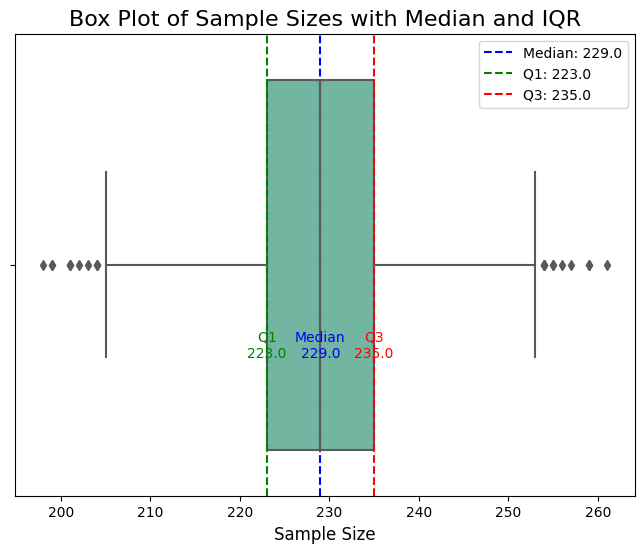

In [7]:
sample_size_df = sample_size.reset_index(name='sample_size')
sample_size_df.columns = ['participant_id', 'sample_size']

# Plotting the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(x=sample_size_df['sample_size'], palette='Set2')

# Add median and IQR annotations
median_value = sample_size_df['sample_size'].median()
q1 = sample_size_df['sample_size'].quantile(0.25)
q3 = sample_size_df['sample_size'].quantile(0.75)
iqr = q3 - q1

# Add annotations
plt.axvline(median_value, color='blue', linestyle='--', label=f"Median: {median_value}")
plt.axvline(q1, color='green', linestyle='--', label=f"Q1: {q1}")
plt.axvline(q3, color='red', linestyle='--', label=f"Q3: {q3}")
plt.text(median_value, 0.2, f'Median\n{median_value}', color='blue', ha='center')
plt.text(q1, 0.2, f'Q1\n{q1}', color='green', ha='center')
plt.text(q3, 0.2, f'Q3\n{q3}', color='red', ha='center')

# Title and labels
plt.title("Box Plot of Sample Sizes with Median and IQR", fontsize=16)
plt.xlabel("Sample Size", fontsize=12)
plt.legend()

# Show the plot
plt.show()

**This validation check identifies impossible negative step values that may indicate data entry or device tracking errors.**

In [8]:
negative_steps = df.loc[df['daily_steps'] < 0, 'participant_id']

In [9]:
negative_steps

207781     905
360838    1573
Name: participant_id, dtype: int64

## Correlation

**Correlation analysis helps identify relationships between fitness variables, metabolic indicators, and exercise intensity levels.**

<Axes: >

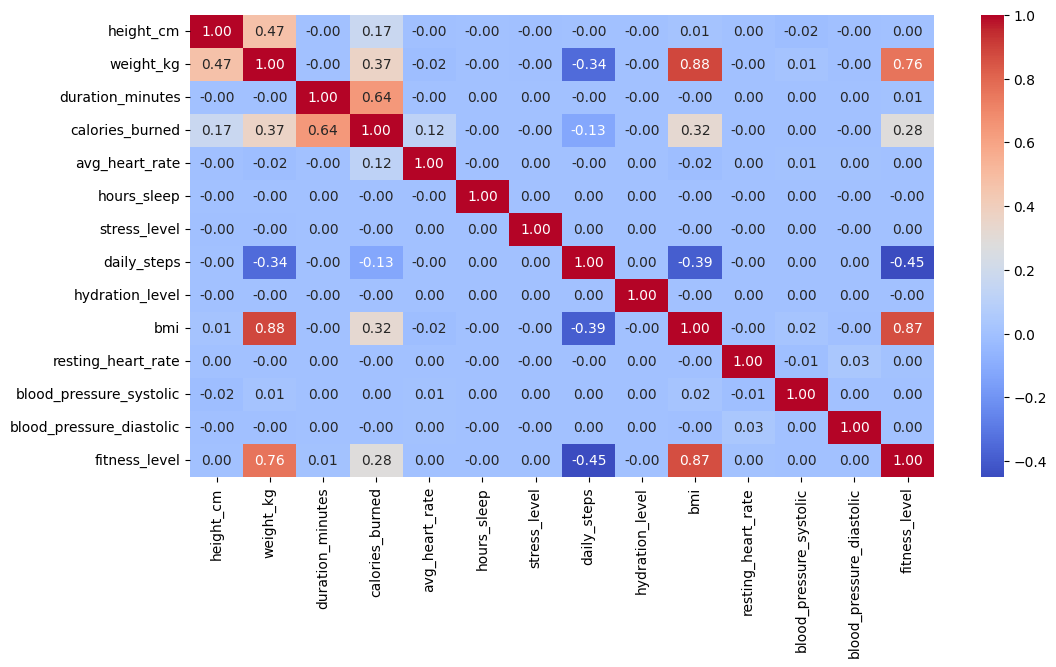

In [10]:
correlation_df = df.drop(["gender","activity_type","intensity","health_condition","smoking_status","participant_id","date","age"], axis=1)
correlation_matrix = correlation_df.corr()

plt.figure(figsize=(12,6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")

Chi-Square Statistic: 3.201558054737898
P-Value: 0.5246793308896304
Degrees of Freedom: 4
Expected Value: 
[[ 22.03596288  34.4837587   88.48027842]
 [ 43.00812065  67.30278422 172.68909513]
 [ 65.95591647 103.21345708 264.83062645]]


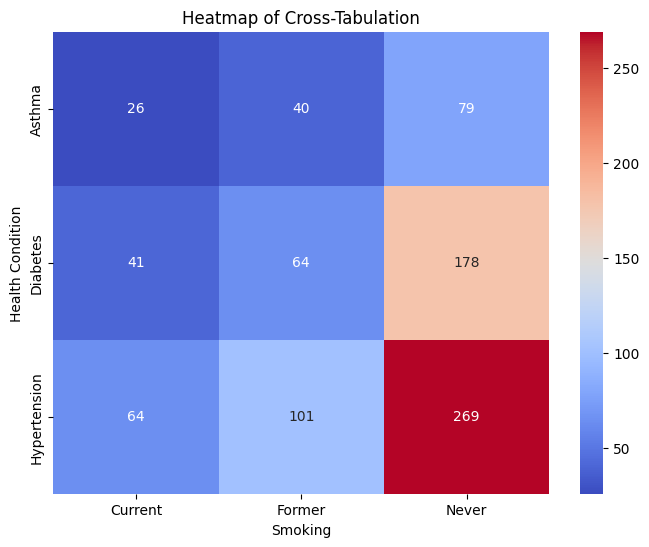

In [11]:
particiapnt_conditions_df = df.groupby('participant_id').first().reset_index()
cross_tabulation = pd.crosstab(particiapnt_conditions_df['health_condition'], 
                               particiapnt_conditions_df['smoking_status'])
chi2, p, dof, expected = chi2_contingency(cross_tabulation)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-Value: {p}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Value: \n{expected}")

plt.figure(figsize=(8, 6))
sns.heatmap(cross_tabulation, annot=True, fmt='d', cmap='coolwarm', cbar=True)
plt.title('Heatmap of Cross-Tabulation')
plt.xlabel('Smoking')
plt.ylabel('Health Condition')
plt.show()

fitness_with_health_df = df.groupby('participant_id').agg({
    'fitness_level': 'mean',
    # Checks if the mode series is empty before accessing index 0
    'smoking_status': lambda x: x.mode()[0] if not x.mode().empty else None,
    'health_condition': lambda x: x.mode()[0] if not x.mode().empty else None
}).reset_index()

## Correlation with fitness growth

This analysis explores whether smoking status may influence fitness level progression and activity trends across participants.

In [12]:
# Calculate fitness growth for each participant
df['fitness_growth'] = df.groupby('participant_id')['fitness_level'].diff().fillna(0)

# Create participant-level summary data
merged_data = df.groupby('participant_id').agg({
    'fitness_growth': 'mean',
    'smoking_status': 'first',
    'health_condition': 'first'
}).reset_index()

# ANOVA test for smoking status
smoking_groups = [
    merged_data[merged_data['smoking_status'] == cat]['fitness_growth']
    for cat in merged_data['smoking_status'].dropna().unique()
]

anova_result = f_oneway(*smoking_groups)

print(
    f"ANOVA for Smoking Status: "
    f"F-statistic = {anova_result.statistic}, "
    f"P-value = {anova_result.pvalue}"
)

# ANOVA test for health condition
health_groups = [
    merged_data[merged_data['health_condition'] == cat]['fitness_growth']
    for cat in merged_data['health_condition'].dropna().unique()
]

anova_health_result = f_oneway(*health_groups)

print(
    f"ANOVA Test for Health Condition: "
    f"F-statistic = {anova_health_result.statistic}, "
    f"P-value = {anova_health_result.pvalue}"
)

ANOVA for Smoking Status: F-statistic = 0.12718785888226836, P-value = 0.8805729872354593
ANOVA Test for Health Condition: F-statistic = 0.4832632796874223, P-value = 0.6169350023803641


Fitness growth trends were calculated to measure participant improvement over time and identify behavioral or health-related patterns.

In [13]:
df['fitness_growth'] = df.groupby('participant_id')['fitness_level'].diff().fillna(df['fitness_level'])

In [14]:
df.head(10)

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,...,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level,fitness_growth
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,...,7128,1.5,19.652988,69.5,110.7,72.9,NaN,Never,0.04,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,...,7925,1.8,19.726183,69.5,110.7,72.9,NaN,Never,0.07,0.03
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,...,7557,2.7,19.835976,69.5,110.7,72.9,NaN,Never,0.09,0.02
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,...,11120,2.6,19.909172,69.5,110.7,72.9,NaN,Never,0.21,0.12
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,...,5406,1.5,20.018965,69.5,110.7,72.9,NaN,Never,0.33,0.12
5,1,2024-01-10,56,F,165.3,54.9,HIIT,31,Medium,6.8,...,10202,2.2,20.092160,69.5,110.7,72.9,NaN,Never,0.37,0.04
6,1,2024-01-11,56,F,165.3,55.2,Weight Training,97,High,12.4,...,5912,2.8,20.201954,69.5,110.7,72.9,NaN,Never,0.51,0.14
7,1,2024-01-12,56,F,165.3,55.5,HIIT,70,Low,12.9,...,9477,1.6,20.311747,69.5,110.7,72.9,NaN,Never,0.58,0.07
8,1,2024-01-17,56,F,165.3,55.7,HIIT,89,Medium,19.7,...,9710,3.3,20.384942,69.5,110.7,72.9,NaN,Never,0.68,0.10
9,1,2024-01-18,56,F,165.3,56.0,Weight Training,115,Medium,12.8,...,7830,2.0,20.494736,69.5,110.7,72.9,NaN,Never,0.82,0.14


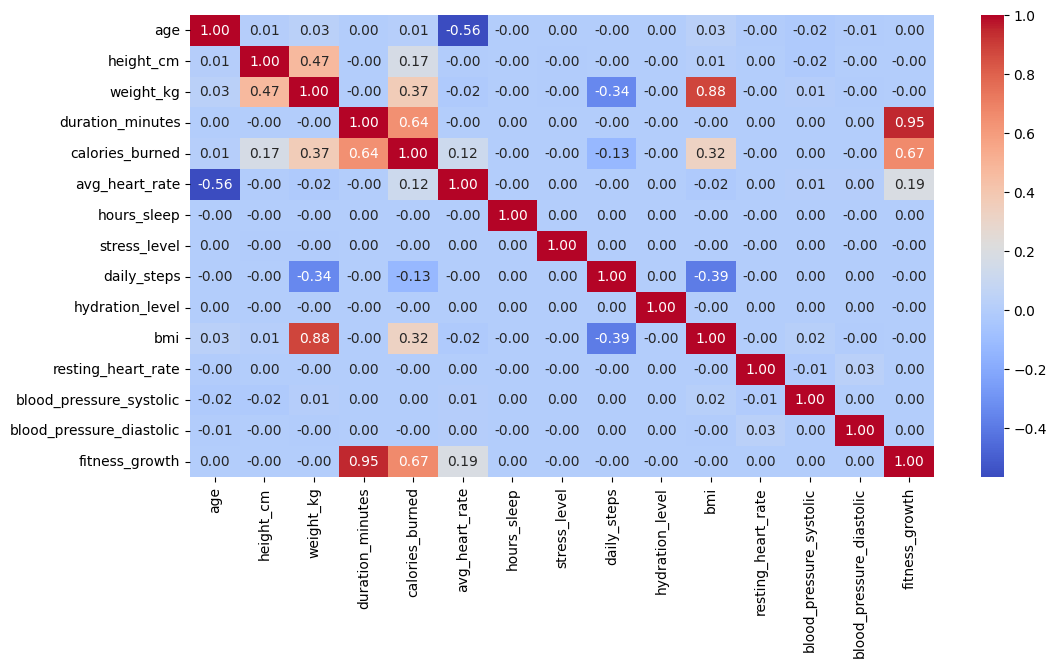

In [15]:
correlation_df = df.drop(
    [
        "gender",
        "activity_type",
        "intensity",
        "health_condition",
        "smoking_status",
        "participant_id",
        "date",
        "fitness_level"
    ],
    axis=1
)

correlation_matrix = correlation_df.corr()

plt.figure(figsize=(12, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.show()

This section evaluates whether underlying health conditions are associated with lower fitness progression rates or reduced activity performance.

In [16]:
find_pearson_df = df.drop(
    [
        "gender",
        "activity_type",
        "intensity",
        "health_condition",
        "smoking_status",
        "participant_id",
        "date",
        "age",
        "fitness_level"
    ],
    axis=1
)

pearson_corr = find_pearson_df.corr(method="pearson")["fitness_growth"]

near_zero_corr = pearson_corr[pearson_corr.abs() < 0.05].index.tolist()

spearman_results = {}

for col in near_zero_corr:
    if col != "fitness_growth":
        corr, p_value = spearmanr(find_pearson_df[col], find_pearson_df["fitness_growth"])
        spearman_results[col] = {
            "Spearman Correlation": corr,
            "P-value": p_value
        }

spearman_df = pd.DataFrame(spearman_results).T

print(spearman_df)

                          Spearman Correlation   P-value
height_cm                            -0.000788  0.513718
weight_kg                            -0.001231  0.307331
hours_sleep                           0.002697  0.025325
stress_level                          0.000334  0.781970
daily_steps                           0.000503  0.676758
hydration_level                      -0.000336  0.780617
bmi                                  -0.000746  0.536343
resting_heart_rate                    0.002486  0.039218
blood_pressure_systolic               0.000823  0.494829
blood_pressure_diastolic              0.000960  0.425856


### Finding significance of activity type with fitness growth

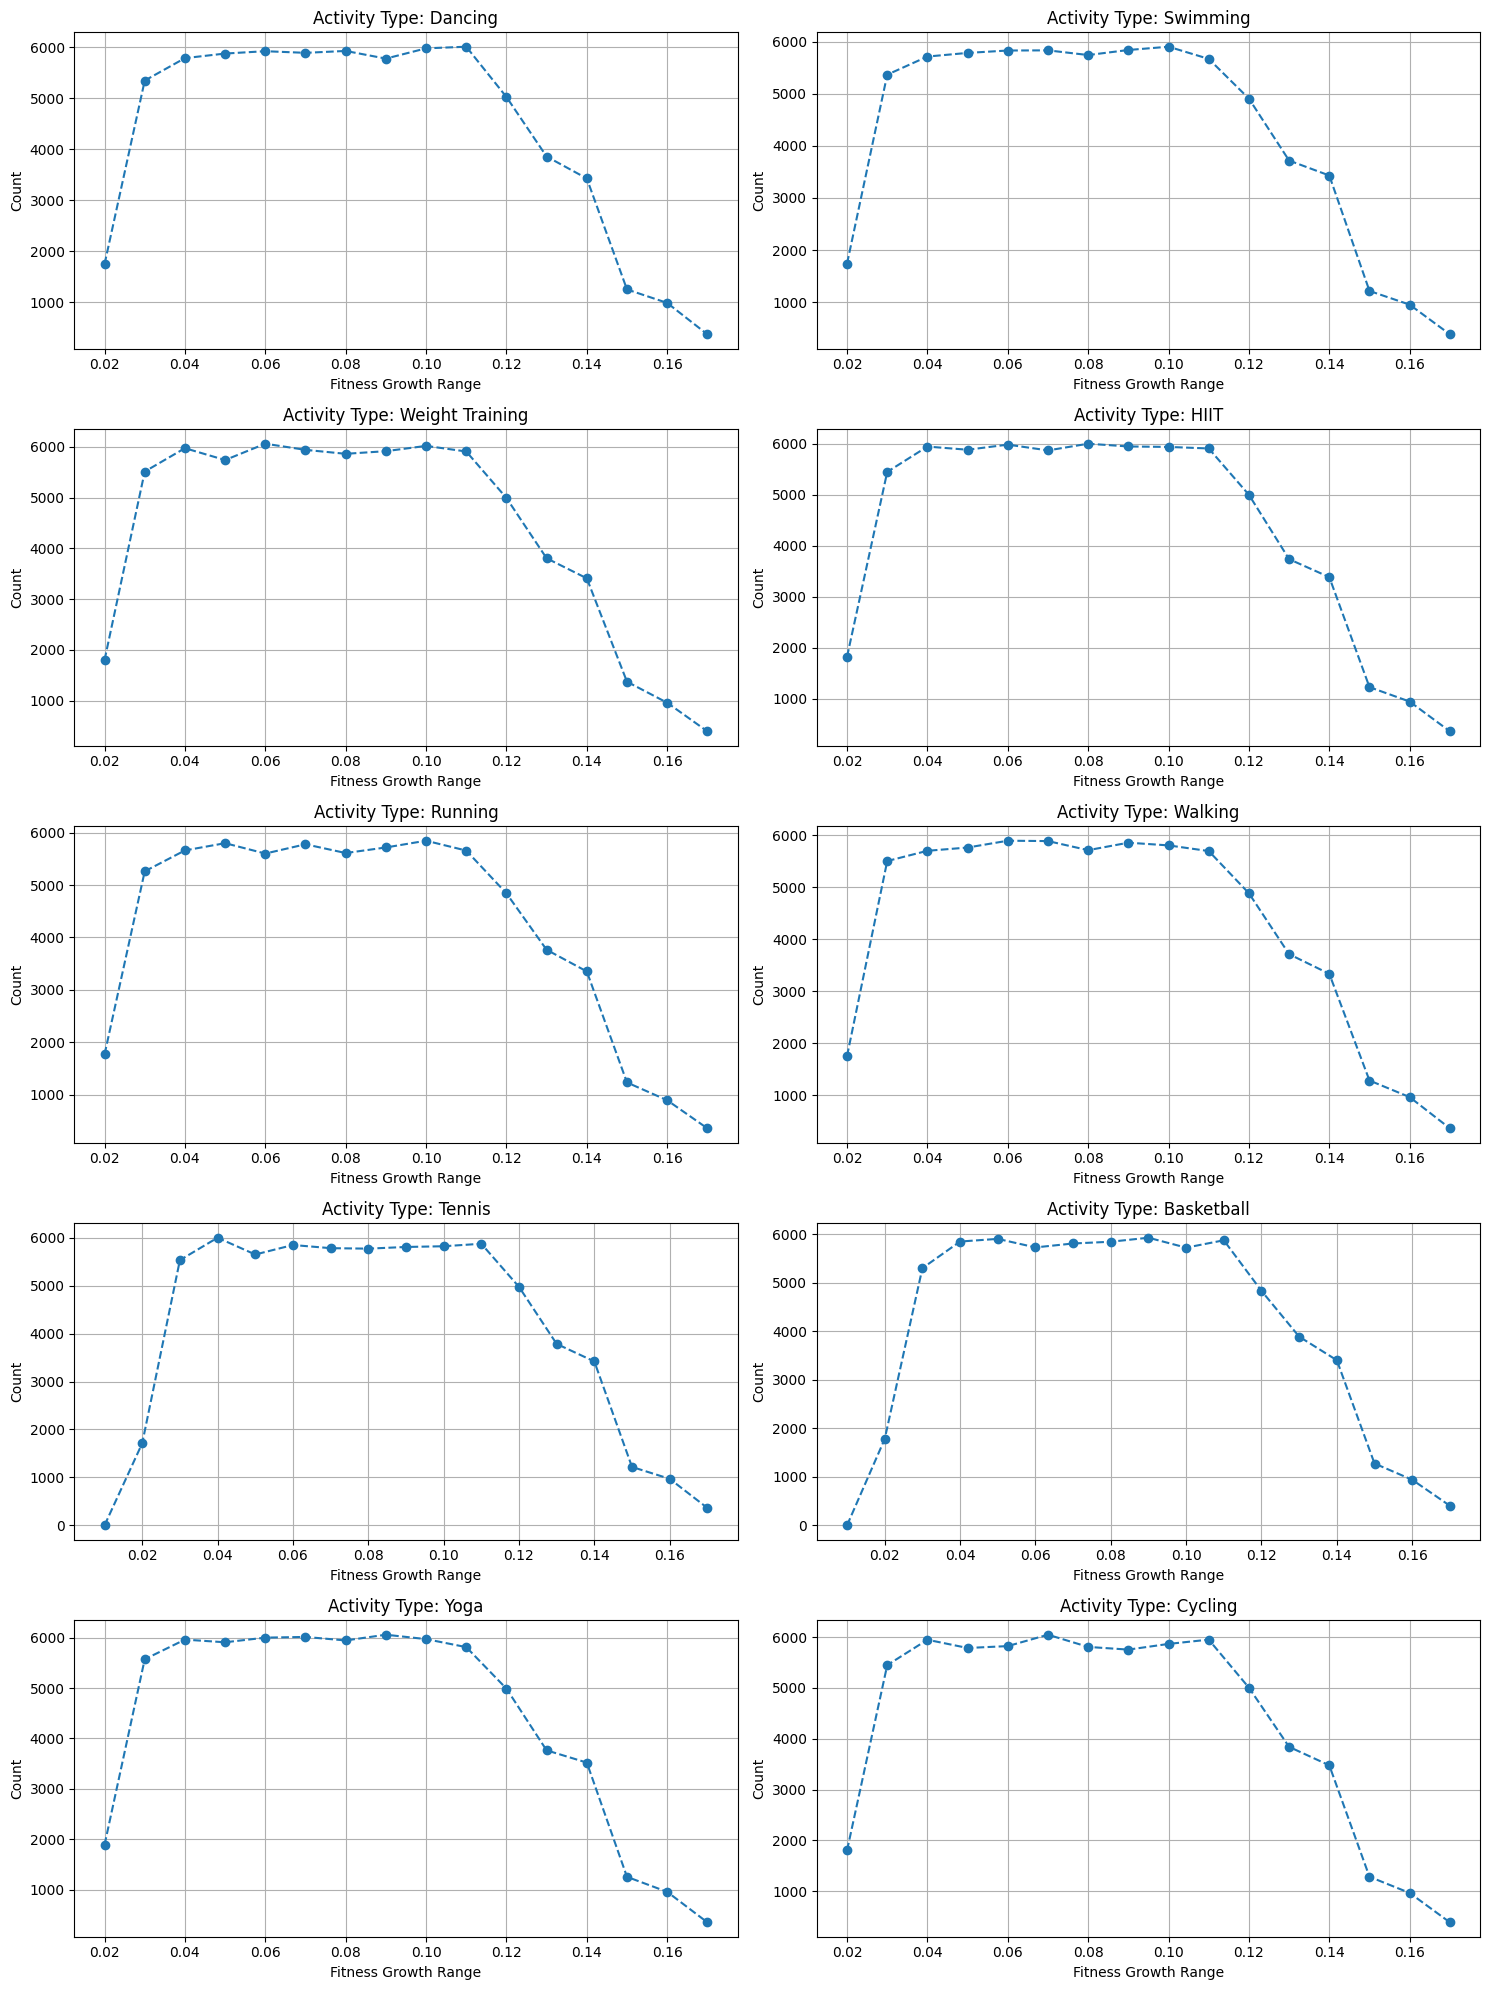

In [17]:
activity_types = df['activity_type'].unique()

fig, axes = plt.subplots(len(activity_types) // 2 + len(activity_types) % 2, 2, figsize=(15, 20))
axes = axes.flatten()

for i, activity in enumerate(activity_types):

    activity_data = df[df['activity_type'] == activity]

    growth_counts = activity_data['fitness_growth'].round(2).value_counts().sort_index()

    axes[i].plot(growth_counts.index, growth_counts.values, marker='o', linestyle='--')
    axes[i].set_title(f'Activity Type: {activity}')
    axes[i].set_xlabel('Fitness Growth Range')
    axes[i].set_ylabel('Count')
    axes[i].grid(True)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

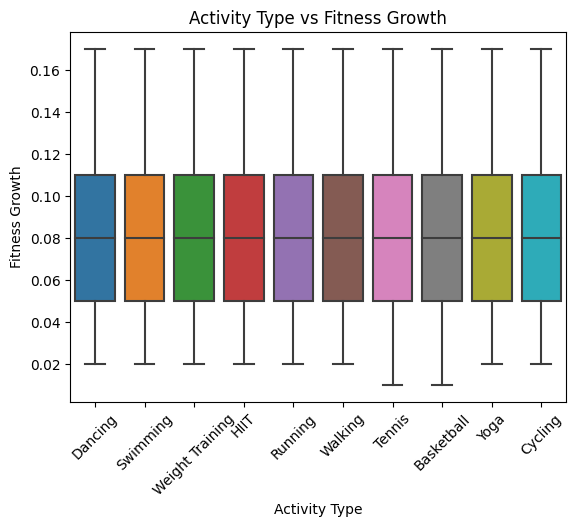

In [18]:
sns.boxplot(x='activity_type', y='fitness_growth', data=df)
plt.title('Activity Type vs Fitness Growth')
plt.xlabel('Activity Type')
plt.ylabel('Fitness Growth')
plt.xticks(rotation=45) 
plt.show()

In [19]:
groups = [
    df[df['activity_type'] == activity]['fitness_growth']
    for activity in df['activity_type'].unique()
]

anova_result = f_oneway(*groups)
print(f"ANOVA Result: F-statistic = {anova_result.statistic}, P-value = {anova_result.pvalue}")

kruskal_result = kruskal(*groups)
print(f"Kruskal-Wallis Test: Statistic = {kruskal_result.statistic}, P-value = {kruskal_result.pvalue}")

ANOVA Result: F-statistic = 1.5970108484488432, P-value = 0.10966113109151672
Kruskal-Wallis Test: Statistic = 13.504149836117232, P-value = 0.14108901913430721


### Finding significance of intensity with fitness growth

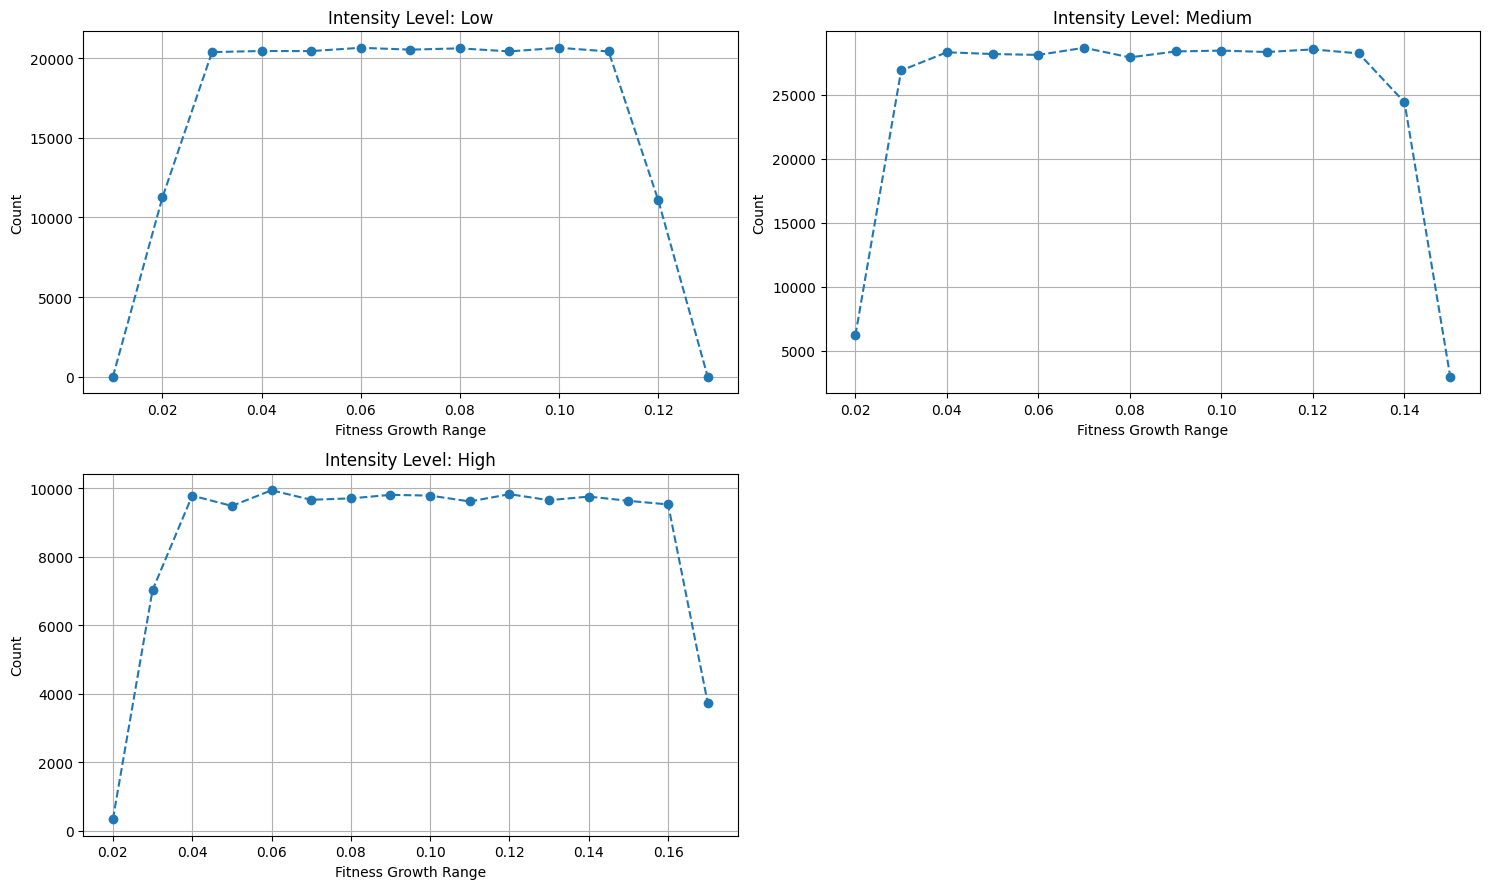

In [20]:
intensity_levels = df['intensity'].unique()

fig, axes = plt.subplots(
    len(intensity_levels) // 2 + len(intensity_levels) % 2,
    2,
    figsize=(15, 9)
)

axes = axes.flatten()

for j, intensity in enumerate(intensity_levels):
    intensity_data = df[df['intensity'] == intensity]

    growth_counts = intensity_data['fitness_growth'].round(2).value_counts().sort_index()

    axes[j].plot(growth_counts.index, growth_counts.values, marker='o', linestyle='--')
    axes[j].set_title(f'Intensity Level: {intensity}')
    axes[j].set_xlabel('Fitness Growth Range')
    axes[j].set_ylabel('Count')
    axes[j].grid(True)

for j in range(j + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

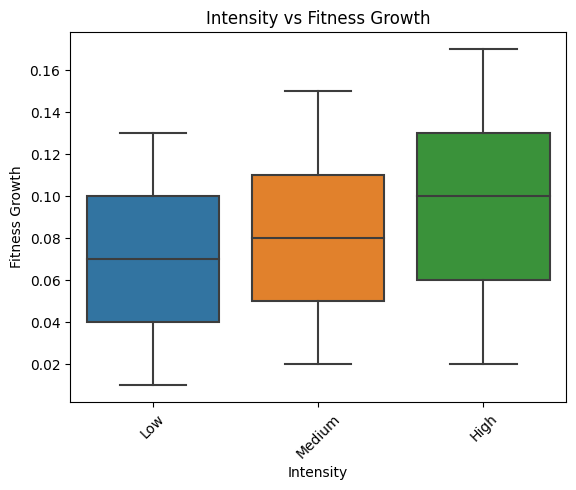

In [21]:
sns.boxplot(x='intensity', y='fitness_growth', data=df)
plt.title('Intensity vs Fitness Growth')
plt.xlabel('Intensity')
plt.ylabel('Fitness Growth')
plt.xticks(rotation=45) 
plt.show()

In [22]:
groups = [
    df[df['intensity'] == intensity]['fitness_growth']
    for intensity in df['intensity'].unique()
]

anova_result = f_oneway(*groups)
print(f"ANOVA Result: F-statistic = {anova_result.statistic}, P-value = {anova_result.pvalue}")

kruskal_result = kruskal(*groups)
print(f"Kruskal-Wallis Test: Statistic = {kruskal_result.statistic}, P-value = {kruskal_result.pvalue}")


ANOVA Result: F-statistic = 27233.352820039207, P-value = 0.0
Kruskal-Wallis Test: Statistic = 42528.11357898183, P-value = 0.0


# Preditive Analysis

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

## Feature Selection

In [24]:
from sklearn.feature_selection import SelectKBest, f_regression
import pandas as pd

X = df.drop(columns=[
    'fitness_growth',
    'fitness_level',
    'participant_id',
    'date',
    'activity_type',
    'gender',
    'health_condition',
    'smoking_status'
])

y = df['fitness_growth']

X_encoded = pd.get_dummies(X, columns=['intensity'], drop_first=True)

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_encoded, y)

feature_scores = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Score': selector.scores_
})

feature_scores_sorted = feature_scores.sort_values(by='Score', ascending=False)

feature_scores_sorted['Score'] = feature_scores_sorted['Score'].apply(lambda x: f"{x:.6f}")

print(feature_scores_sorted)

                     Feature           Score
3           duration_minutes  6285277.623282
4            calories_burned   550311.831808
14             intensity_Low    37817.713257
5             avg_heart_rate    25482.788156
15          intensity_Medium     1071.064793
11        resting_heart_rate        6.004586
6                hours_sleep        5.021220
2                  weight_kg        1.121640
1                  height_cm        0.583200
10                       bmi        0.417931
0                        age        0.413774
12   blood_pressure_systolic        0.285192
13  blood_pressure_diastolic        0.099254
9            hydration_level        0.056010
8                daily_steps        0.023174
7               stress_level        0.000030


In [25]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       687701 non-null  int64  
 1   height_cm                 687701 non-null  float64
 2   weight_kg                 687701 non-null  float64
 3   duration_minutes          687701 non-null  int64  
 4   intensity                 687701 non-null  object 
 5   calories_burned           687701 non-null  float64
 6   avg_heart_rate            687701 non-null  int64  
 7   hours_sleep               687701 non-null  float64
 8   stress_level              687701 non-null  int64  
 9   daily_steps               687701 non-null  int64  
 10  hydration_level           687701 non-null  float64
 11  bmi                       687701 non-null  float64
 12  resting_heart_rate        687701 non-null  float64
 13  blood_pressure_systolic   687701 non-null  f

In [26]:
intensity_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
X['intensity'] = X['intensity'].map(intensity_mapping)

print(X['intensity'].dtype)

int64


## Train-test-val Split

In [27]:
train_size = 0.7 
val_size = 0.15  
test_size = 0.15 

X_train, X_remaining, y_train, y_remaining = train_test_split(X, y, test_size=(val_size + test_size), random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_remaining, y_remaining, test_size=(test_size / (val_size + test_size)), random_state=42)

## XGBoost Regression

In [28]:
xgBoostModel = XGBRegressor(early_stopping_rounds=5)
xgBoostModel.fit(X_train, y_train, eval_set=[(X_test, y_test)])

[0]	validation_0-rmse:0.02551
[1]	validation_0-rmse:0.01812
[2]	validation_0-rmse:0.01303
[3]	validation_0-rmse:0.00958
[4]	validation_0-rmse:0.00732
[5]	validation_0-rmse:0.00590
[6]	validation_0-rmse:0.00506
[7]	validation_0-rmse:0.00459
[8]	validation_0-rmse:0.00434
[9]	validation_0-rmse:0.00422
[10]	validation_0-rmse:0.00415
[11]	validation_0-rmse:0.00412
[12]	validation_0-rmse:0.00411
[13]	validation_0-rmse:0.00410
[14]	validation_0-rmse:0.00409
[15]	validation_0-rmse:0.00409
[16]	validation_0-rmse:0.00409
[17]	validation_0-rmse:0.00409
[18]	validation_0-rmse:0.00409
[19]	validation_0-rmse:0.00409
[20]	validation_0-rmse:0.00409
[21]	validation_0-rmse:0.00409
[22]	validation_0-rmse:0.00409
[23]	validation_0-rmse:0.00409


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=5,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [29]:
y_pred = xgBoostModel.predict(X_test)

In [30]:
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r_squared = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R-squared (R2): {r_squared:.4f}")

Mean Absolute Error (MAE): 0.0033
Mean Squared Error (MSE): 0.0000
Root Mean Squared Error (RMSE): 0.0041
Mean Absolute Percentage Error (MAPE): 5.25%
R-squared (R2): 0.9872


## Key Findings

- Higher activity intensity levels were associated with increased calorie expenditure.
- Certain health conditions appeared linked to reduced fitness growth trends.
- Smoking status showed measurable differences across wellness indicators.
- Wearable fitness tracking data can support predictive healthcare and preventative wellness analysis.

## Conclusion

This analysis demonstrates how wearable fitness data can support predictive wellness analytics and preventative healthcare strategies. By combining exploratory analysis with visualization and predictive modeling, the project highlights how activity trends and metabolic indicators may help organizations better understand health behavior patterns.